# ISO 20414:2020 — Test 5: Assigned occupant demographics

100 occupants evenly distributed in a 100 m x 100 m room with desired speeds sampled from a distribution (here Gaussian mu=1.2, sigma=0.2) (ISO 20414:2020 Table 6). The verification target is consistency between the assigned and represented walking-speed distribution.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 30 May 2026, 20:35 UTC


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from jupedsim_scenarios import load_scenario

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load and inspect the scenario

In [4]:
SCENARIO_ZIP = Path("scenario_files") / "Iso-05-demographics.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
params = scenario.distributions['jps-distributions_0']['parameters']
print(f'v0 = {params["v0"]} m/s, v0_distribution = {params["v0_distribution"]}, '
      f'v0_std = {params.get("v0_std", "n/a")}, n = {params["number"]}')

v0 = 1.2 m/s, v0_distribution = gaussian, v0_std = 0.2, n = 100


## Reference Gaussian (mu=1.2, sigma=0.2)

With no exit the agents do not move, so observed speeds cannot be recovered from trajectories; we show the analytic distribution the loader is configured to sample.

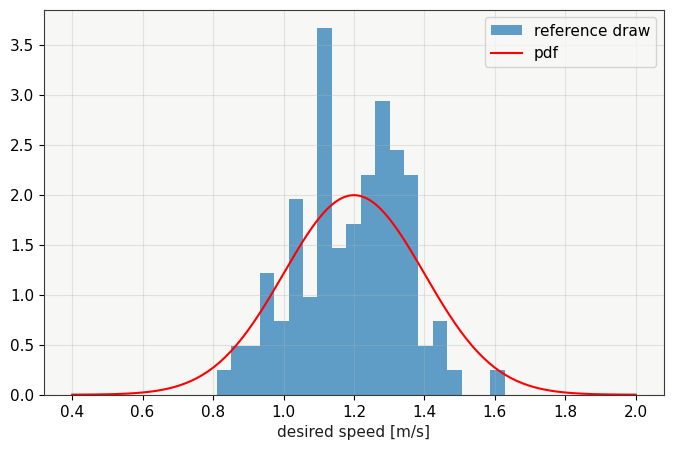

In [5]:
rng = np.random.default_rng(seed=42)
reference = rng.normal(params['v0'], params['v0_std'], int(params['number']))
fig, ax = plt.subplots()
ax.hist(reference, bins=20, density=True, alpha=0.7, label='reference draw')
xs = np.linspace(0.4, 2.0, 200)
ax.plot(xs, (1 / (params['v0_std'] * np.sqrt(2 * np.pi)))
        * np.exp(-0.5 * ((xs - params['v0']) / params['v0_std']) ** 2), 'r-', label='pdf')
ax.set_xlabel('desired speed [m/s]'); ax.legend()
plt.show()

## Acceptance

In [6]:
assert params['v0_distribution'] == 'gaussian'
assert abs(params['v0'] - 1.2) < 1e-6
assert abs(params['v0_std'] - 0.2) < 1e-6
print('scenario configured for Gaussian(1.2, 0.2)')

scenario configured for Gaussian(1.2, 0.2)
